In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 79.8 MB/s eta 0:00:00


PyTorch will use device: cpu

LOADING PRE-PROCESSED DATA FOR 26-CLASS PROBLEM
Loading from: /kaggle/input/final-feature-extracted-ransap/RANSAP_win7-120gb-ssd_26CLASS.npy
Using labels directly from the file without transformation.

Balancing dataset...
Balancing all 26 classes to 1000 samples each.

DATASET SUMMARY
Training set: 20800 samples | Test set: 5200 samples

⚠️ Using CPU-only quantum simulator (5 qubits)

Starting training...
Epoch 1/25 - Loss: 3.2653
Epoch 2/25 - Loss: 3.2416
Epoch 3/25 - Loss: 3.2154
Epoch 4/25 - Loss: 3.1846
Epoch 5/25 - Loss: 3.1502
Epoch 6/25 - Loss: 3.1176
Epoch 7/25 - Loss: 3.0821
Epoch 8/25 - Loss: 3.0465
Epoch 9/25 - Loss: 3.0163
Epoch 10/25 - Loss: 2.9870
Epoch 11/25 - Loss: 2.9540
Epoch 12/25 - Loss: 2.9274
Epoch 13/25 - Loss: 2.8994
Epoch 14/25 - Loss: 2.8767
Epoch 15/25 - Loss: 2.8487
Epoch 16/25 - Loss: 2.8289
Epoch 17/25 - Loss: 2.8094
Epoch 18/25 - Loss: 2.7931
Epoch 19/25 - Loss: 2.7711
Epoch 20/25 - Loss: 2.7551
Epoch 21/25 - Loss: 2.7449
Ep

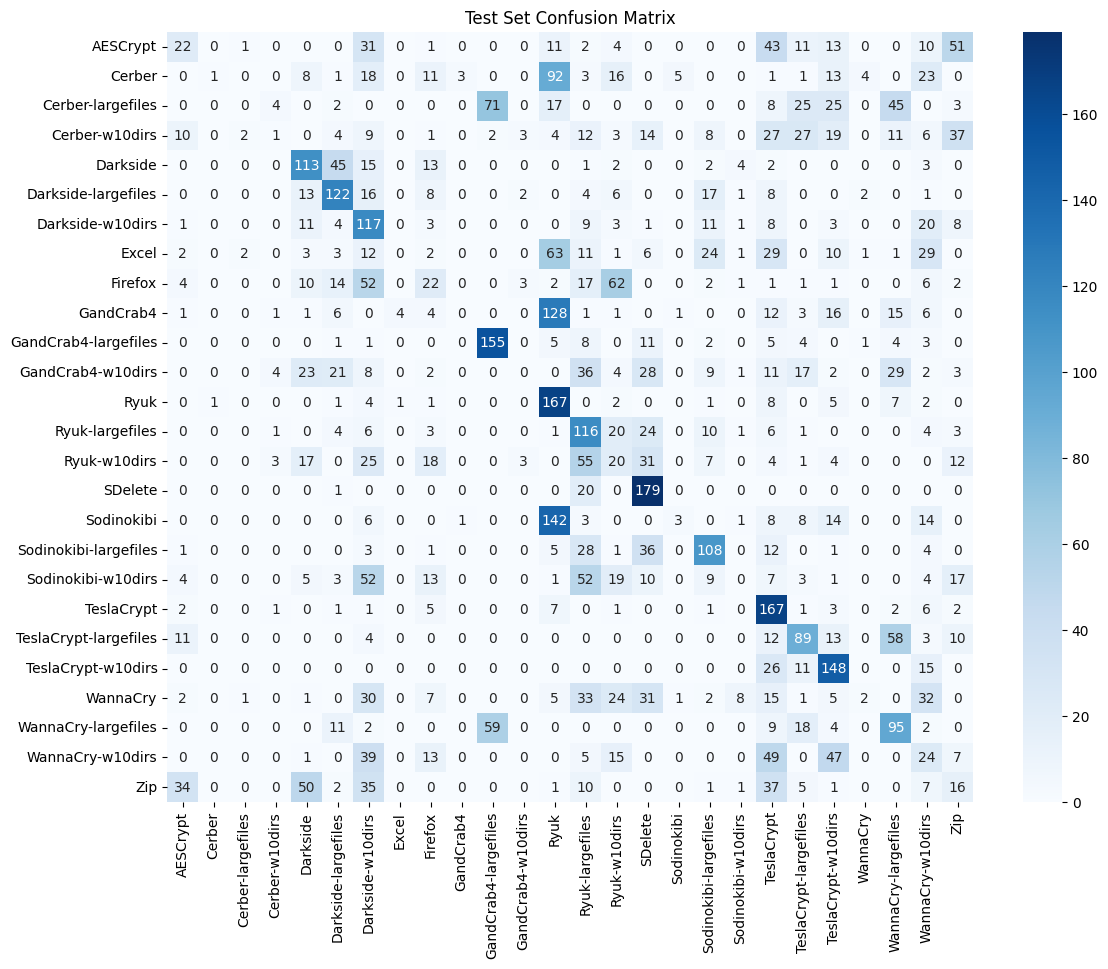



Training pipeline completed successfully!


In [2]:
# In a Kaggle notebook cell, run this command FIRST and restart the kernel:
# !pip install pennylane-lightning[gpu] cuquantum-python --upgrade

import torch
import torch.nn as nn
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# --- Global Device Selection ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch will use device: {device}")

# --- Classification Setup ---
# This dictionary is now used for naming the final output classes
CLASS_CONFIG = {
    26: {
        "AESCrypt": 0, "Cerber": 1, "Cerber-largefiles": 2, "Cerber-w10dirs": 3,
        "Darkside": 4, "Darkside-largefiles": 5, "Darkside-w10dirs": 6, "Excel": 7,
        "Firefox": 8, "GandCrab4": 9, "GandCrab4-largefiles": 10, "GandCrab4-w10dirs": 11,
        "Ryuk": 12, "Ryuk-largefiles": 13, "Ryuk-w10dirs": 14, "SDelete": 15,
        "Sodinokibi": 16, "Sodinokibi-largefiles": 17, "Sodinokibi-w10dirs": 18,
        "TeslaCrypt": 19, "TeslaCrypt-largefiles": 20, "TeslaCrypt-w10dirs": 21,
        "WannaCry": 22, "WannaCry-largefiles": 23, "WannaCry-w10dirs": 24, "Zip": 25
    },
    12: {
        "AESCrypt": 0, "Cerber": 1, "Darkside": 2, "Excel": 3, "Firefox": 4,
        "GandCrab4": 5, "Ryuk": 6, "SDelete": 7, "Sodinokibi": 8, "TeslaCrypt": 9,
        "WannaCry": 10, "Zip": 11
    },
    2: { "Benign": 0, "Ransomware": 1 }
}

# --- Hybrid Quantum-Classical Model ---
class HybridQNN(nn.Module):
    def __init__(self, n_inputs, n_expanded_features, n_layers, n_classes):
        super().__init__()
        
        # Classical pre-processing network
        self.classical_pre_net = nn.Sequential(
            nn.Linear(n_inputs, n_expanded_features * 2),
            nn.ReLU(),
            nn.Linear(n_expanded_features * 2, n_expanded_features)
        )
        
        # Quantum circuit setup
        n_qubits = n_expanded_features
        try:
            if device.type == 'cuda':
                self.dev = qml.device("lightning.gpu", wires=n_qubits)
                print(f"\n✅ Using GPU-accelerated quantum simulator ({n_qubits} qubits)")
            else:
                raise ImportError("CUDA not available")
        except Exception:
            self.dev = qml.device("lightning.qubit", wires=n_qubits)
            print(f"\n⚠️ Using CPU-only quantum simulator ({n_qubits} qubits)")

        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            for l in range(n_layers):
                for i in range(n_qubits):
                    qml.RY(weights[l, i, 0], wires=i)
                    qml.RZ(weights[l, i, 1], wires=i)
                # Correctly implement the ring entanglement layer with a for loop
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                if n_qubits > 1:
                    qml.CNOT(wires=[n_qubits - 1, 0])
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.circuit = circuit
        weight_shape = (n_layers, n_qubits, 2)
        self.q_weights = nn.Parameter(0.01 * torch.randn(weight_shape))

        # Classical post-processing network
        self.classical_post_net = nn.Sequential(
            nn.Linear(n_qubits, n_qubits * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_qubits * 2, n_classes)
        )

    def forward(self, x):
        expanded_features = self.classical_pre_net(x)
        q_out_list = [self.circuit(x_i, self.q_weights) for x_i in expanded_features]
        # Correctly convert the list of lists into a single 2D tensor
        quantum_features = torch.tensor(q_out_list, dtype=torch.float32, device=x.device)
        return self.classical_post_net(quantum_features)

# --- CORRECTED Data Loading Function ---
def load_data_from_npy(file_path: str, test_ratio: float, num_classes: int, max_samples_per_class: int = None):
    print("\n" + "="*50)
    print(f"LOADING PRE-PROCESSED DATA FOR {num_classes}-CLASS PROBLEM")
    print(f"Loading from: {file_path}")
    print("="*50)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path)
    X = data[:, :-1].astype(np.float32)
    y = data[:, -1].astype(int)
    
    # ASSUME LABELS ARE ALREADY CORRECT FOR THE GIVEN FILE (0-1, 0-11, or 0-25)
    y_processed = y
    print("Using labels directly from the file without transformation.")
    
    print("\nBalancing dataset...")
    unique, counts = np.unique(y_processed, return_counts=True)
    min_samples = np.min(counts)
    balance_to = min(min_samples, max_samples_per_class) if max_samples_per_class else min_samples
    print(f"Balancing all {len(unique)} classes to {balance_to} samples each.")
    
    balanced_indices = []
    for label in unique:
        indices = np.where(y_processed == label)[0]
        chosen_indices = np.random.choice(indices, balance_to, replace=False)
        balanced_indices.append(chosen_indices)
    
    balanced_indices = np.concatenate(balanced_indices)
    np.random.shuffle(balanced_indices)
    
    X_balanced = X[balanced_indices]
    y_balanced = y_processed[balanced_indices]

    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced, test_size=test_ratio, random_state=42, stratify=y_balanced
    )
    
    print("\n" + "="*50)
    print("DATASET SUMMARY")
    print(f"Training set: {len(X_train)} samples | Test set: {len(X_test)} samples")
    return X_train, y_train, X_test, y_test

# --- Training and Evaluation ---
def train_and_evaluate(X_train, y_train, X_test, y_test, num_classes, n_expanded_features, n_layers, epochs, batch_size, lr):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    train_dataset = TensorDataset(torch.from_numpy(X_train_scaled), torch.from_numpy(y_train))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    model = HybridQNN(
        n_inputs=X_train.shape[1],
        n_expanded_features=n_expanded_features,
        n_layers=n_layers,
        n_classes=num_classes
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    print("\nStarting training...")
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

    print("\nEvaluating on test set...")
    model.eval()
    test_preds = []
    with torch.no_grad():
        test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test_scaled)), batch_size=batch_size)
        for X_batch_test in test_loader:
            X_batch_test = X_batch_test[0].to(device)
            test_outputs = model(X_batch_test)
            _, batch_preds = torch.max(test_outputs, 1)
            test_preds.extend(batch_preds.cpu().numpy())
    
    test_preds = np.array(test_preds)
    test_acc = accuracy_score(y_test, test_preds)
    print(f"\nTest Set Accuracy: {test_acc:.4f}")
    
    class_names = list(CLASS_CONFIG[num_classes].keys())
    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names, digits=4, zero_division=0))
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(max(8, len(class_names)//2), max(6, len(class_names)//2.5)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Test Set Confusion Matrix')
    plt.savefig('hybrid_qnn_confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()

    return model

# --- Main Execution ---
if __name__ == "__main__":
    # --- CONFIGURATION ---
    # Choose the number of classes: 2, 12, or 26.
    NUM_CLASSES = 26
    
    # WARNING: Increasing this number drastically increases runtime.
    N_EXPANDED_FEATURES = 5 # (This will create an 8-qubit circuit)

    # Set to None to use the full balanced dataset for the highest accuracy.
    MAX_SAMPLES_PER_CLASS = 1000 
    
    # This dictionary maps your choice of classes to the correct Kaggle file path
    KAGGLE_FILE_PATHS = {
        2: "/kaggle/input/ransap-feature-extracted-ssd-2class/RANSAP_win7-120gb-ssd_2CLASS.npy",
        12: "/kaggle/input/ransap-feature-extracted-ssd-12class/RANSAP_win7-120gb-ssd_12CLASS.npy",
        26: "/kaggle/input/final-feature-extracted-ransap/RANSAP_win7-120gb-ssd_26CLASS.npy"
    }
    
    # Select the correct file path based on the number of classes
    NPY_FILE = KAGGLE_FILE_PATHS[NUM_CLASSES]
    
    if not os.path.exists(NPY_FILE):
        print(f"FATAL: The file was not found -> '{NPY_FILE}'")
    else:
        X_train, y_train, X_test, y_test = load_data_from_npy(
            file_path=NPY_FILE,
            test_ratio=0.2,
            num_classes=NUM_CLASSES,
            max_samples_per_class=MAX_SAMPLES_PER_CLASS
        )
        
        model = train_and_evaluate(
            X_train, y_train, X_test, y_test,
            num_classes=NUM_CLASSES,
            n_expanded_features=N_EXPANDED_FEATURES,
            n_layers=4, 
            epochs=25, 
            batch_size=32,
            lr=0.001
        )
        if model:
            print("\n\nTraining pipeline completed successfully!")



